In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


In [5]:
start = '2010-01-01'
end = '2025-12-31'

df=yf.download('HDB',start=start,end=end)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,HDB,HDB,HDB,HDB,HDB
Date,,,,,
2010-01-04,5.794820,5.795688,5.715362,5.763992,4234000
2010-01-05,5.819571,5.819571,5.753139,5.764862,3812000
2010-01-06,5.845622,5.866029,5.753137,5.753137,2586000
2010-01-07,5.938974,5.943750,5.796557,5.799596,5888000
2010-01-08,5.956778,5.970238,5.819137,5.819137,3424000


In [6]:
df.tail()


Price,Close,High,Low,Open,Volume
Ticker,HDB,HDB,HDB,HDB,HDB
Date,,,,,
2025-12-23,36.279999,36.570000,36.180000,36.340000,2471800
2025-12-24,36.400002,36.439999,36.160000,36.160000,1536800
2025-12-26,36.459999,36.459999,36.110001,36.169998,2261300
2025-12-29,36.340000,36.439999,36.020000,36.070000,2560100
2025-12-30,36.439999,36.660000,36.320000,36.360001,2780700


In [7]:
df=df.reset_index()
df.head()
df.tail()

Price,Date,Close,High,Low,Open,Volume
Ticker,,HDB,HDB,HDB,HDB,HDB
4018,2025-12-23,36.279999,36.570000,36.180000,36.340000,2471800
4019,2025-12-24,36.400002,36.439999,36.160000,36.160000,1536800
4020,2025-12-26,36.459999,36.459999,36.110001,36.169998,2261300
4021,2025-12-29,36.340000,36.439999,36.020000,36.070000,2560100
4022,2025-12-30,36.439999,36.660000,36.320000,36.360001,2780700


In [8]:
df=df.drop(['Date'],axis=1)
df.head()
# print(df.columns)

C:\Users\udbha\AppData\Local\Temp\ipykernel_4388\587565687.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df=df.drop(['Date'],axis=1)


Price,Close,High,Low,Open,Volume
Ticker,HDB,HDB,HDB,HDB,HDB
0,5.794820,5.795688,5.715362,5.763992,4234000
1,5.819571,5.819571,5.753139,5.764862,3812000
2,5.845622,5.866029,5.753137,5.753137,2586000
3,5.938974,5.943750,5.796557,5.799596,5888000
4,5.956778,5.970238,5.819137,5.819137,3424000


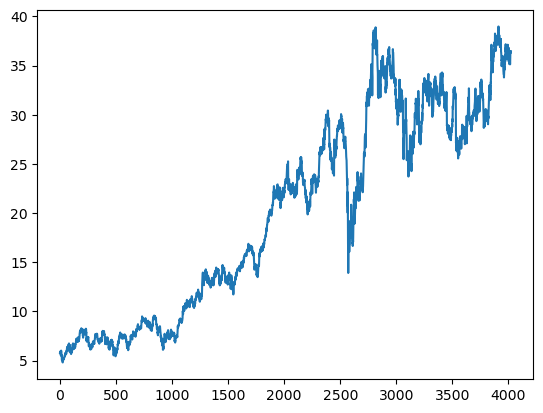

In [9]:
plt.plot(df.Close)

In [10]:
ma100=df.Close.rolling(100).mean()
ma100

Ticker,HDB
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4018,35.954977
4019,35.940420
4020,35.930176
4021,35.917989


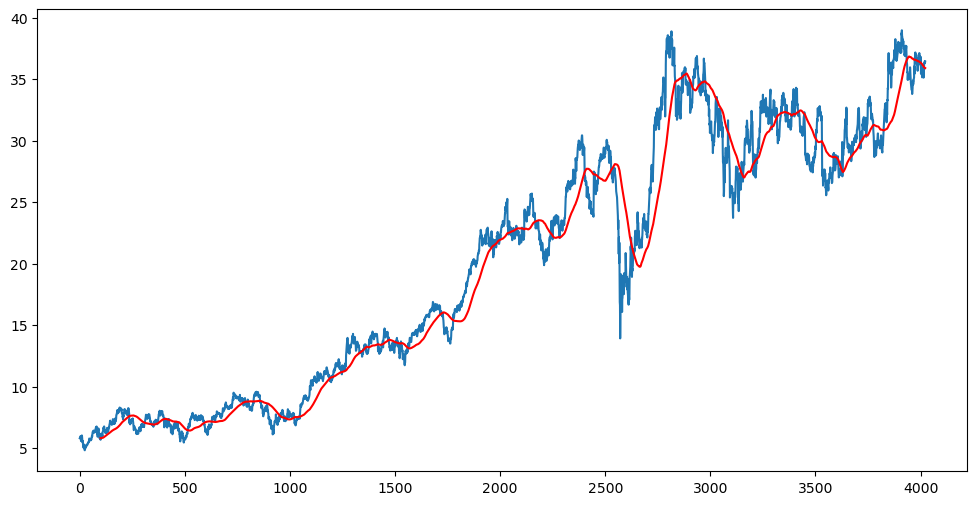

In [11]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100,'r')

In [12]:
ma200=df.Close.rolling(200).mean()
ma200

Ticker,HDB
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4018,35.786692
4019,35.820982
4020,35.853943
4021,35.887414


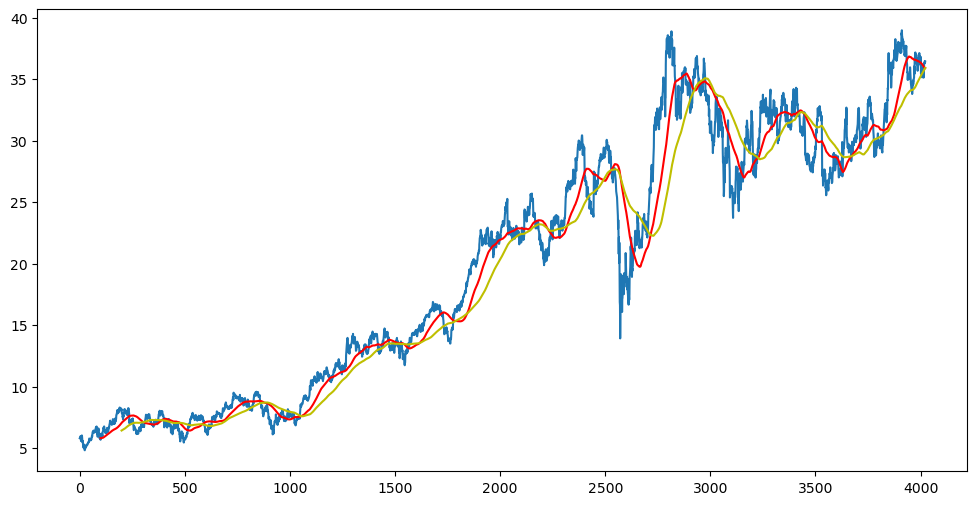

In [13]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100,'r')
plt.plot(ma200,'y')

In [14]:
df.shape

(4023, 5)

In [15]:
#Splitting Data into training and Testing

data_training=pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing=pd.DataFrame(df['Close'][int(len(df)*0.70):int(len(df))])
print(data_testing.shape)
print(data_training.shape)

(1207, 1)
(2816, 1)


In [16]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))

In [17]:
data_training_array=scaler.fit_transform(data_training)
data_training_array

array([[0.02882702],
       [0.02955316],
       [0.03031743],
       ...,
       [0.99332329],
       [0.9896441 ],
       [1.        ]], shape=(2816, 1))

In [18]:
x_train=[]
y_train=[]

for i in range(100,data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i,0])

x_train,y_train=np.array(x_train),np.array(y_train)

In [19]:
#ML Model
import keras_core as keras
from keras.layers import Dense,Dropout,LSTM
from keras.models import Sequential

In [58]:
model = Sequential()

# First LSTM layer
model.add(LSTM(units=50, activation='relu', return_sequences=True,
               input_shape=(x_train.shape[1],1)))
model.add(Dropout(0.2))

# Second LSTM layer
model.add(LSTM(units=60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))

# Third LSTM layer
model.add(LSTM(units=80, activation='relu', return_sequences=True))
model.add(Dropout(0.4))

# Last LSTM layer (IMPORTANT)
model.add(LSTM(units=120, activation='relu', return_sequences=False))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

C:\Users\udbha\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [59]:


model.fit(x_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - loss: 0.0213
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.0047
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.0041
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.0040
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - loss: 0.0036
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.0036
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - loss: 0.0036
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - loss: 0.0033
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0036
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - loss: 0.0028
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.0029
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - loss: 0.0028
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - loss: 0.0026
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.0028
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/

In [60]:
model.save('keras_model.keras')

In [61]:
past_100_days=data_training.tail(100)


In [62]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [63]:
final_df.head()

Ticker,HDB
0,26.009430
1,26.659666
2,27.356346
3,27.765066
4,27.876534


In [65]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.14995282],
       [0.19255272],
       [0.23819537],
       ...,
       [0.83461675],
       [0.82675507],
       [0.83330643]], shape=(1307, 1))

In [64]:
x_test=[]
y_test=[]

for i in range(100,input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])

x_test,y_test=np.array(x_test),np.array(y_test)

In [66]:
y_predicted=model.predict(x_test)

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step


In [68]:
y_predicted.shape

(1207, 1)

In [70]:
scaler.scale_

array([0.06551451])

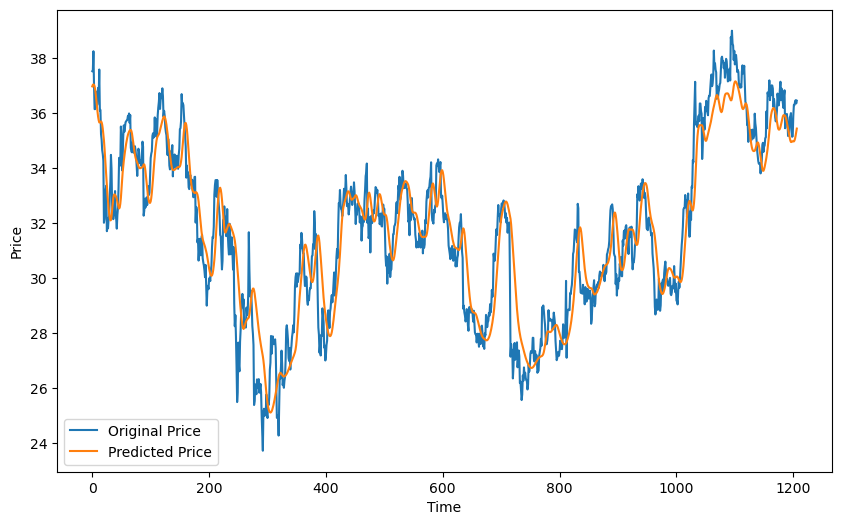

In [71]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1,1))
y_test = scaler.inverse_transform(y_test.reshape(-1,1))

plt.figure(figsize=(10,6))

plt.plot(y_test, label="Original Price")
plt.plot(y_predicted, label="Predicted Price")

plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()

plt.show()